# 01 EDA & Feature Engineering: College Football Attendance


## Import libraries and the datasets

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_DATA_DIR = Path("../data/raw")

games_df = pd.read_csv(RAW_DATA_DIR / "cfbd_games_2023_2025.csv")
fbs_stadiums_df = pd.read_csv(RAW_DATA_DIR / "fbs-stadiums-original.csv")
fcs_stadiums_df = pd.read_csv(RAW_DATA_DIR / "fcs-stadiums-original.csv")
geocoded_stad_df = pd.read_csv(RAW_DATA_DIR / "stadiums-geocoded.csv")

### Make sure that datasets are loaded

In [12]:
games_df.head()

,id,season,week,seasonType,startDate,startTimeTBD,completed,neutralSite,conferenceGame,attendance,...,awayConference,awayPoints,awayLineScores,awayPostgameWinProbability,awayPregameElo,awayPostgameElo,excitementIndex,highlights,notes,playoff
0,401525434,2023,1,regular,2023-08-26T18:30:00.000Z,False,True,True,False,49000.0,...,American Athletic,3.0,"[0, 0, 0, 3]",0.023594,1471.0,1385.0,1.646466,NaN,NaN,NaN
1,401540199,2023,1,regular,2023-08-26T19:30:00.000Z,False,True,True,False,NaN,...,UAC,7.0,"[7, 0, 0, 0]",0.031442,NaN,NaN,4.165937,NaN,NaN,NaN
2,401520145,2023,1,regular,2023-08-26T21:30:00.000Z,False,True,False,True,17982.0,...,Conference USA,14.0,"[0, 7, 0, 7]",0.192517,1369.0,1370.0,4.604490,NaN,NaN,NaN
3,401525450,2023,1,regular,2023-08-26T23:00:00.000Z,False,True,False,False,15356.0,...,FBS Independents,41.0,"[7, 3, 3, 28]",0.882491,1074.0,1122.0,5.430058,NaN,NaN,NaN
4,401532392,2023,1,regular,2023-08-26T23:00:00.000Z,False,True,False,False,23867.0,...,Mid-American,13.0,"[3, 3, 0, 7]",0.121683,1482.0,1473.0,5.105937,NaN,NaN,NaN


In [13]:
fbs_stadiums_df.head()

,image,stadium,city,state,team,conference,capacity,built,expanded
0,Michigan Stadium 2011.jpg,Michigan Stadium,Ann Arbor,MI,Michigan,Big Ten,"107,601[98]",1927,2015
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Beaver Stadium inside.jpg,Beaver Stadium,University Park,PA,Penn State,Big Ten,"106,572[12]",1960,2001
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Ohio Stadium, Columbus.jpg",Ohio Stadium,Columbus,OH,Ohio State,Big Ten,"104,944[106]",1922[108],2014[108]


In [14]:
fcs_stadiums_df.head()

,image,stadium,city,state,team,conference,capacity,built,expanded
0,LP Field 2009 crop.jpg,LP Field,Nashville,Tennessee,Tennessee State Tigers,Ohio Valley,"68,798",1999,NaN
1,Yale bowl birds eye view.png,Yale Bowl,New Haven,Connecticut,Yale Bulldogs,Ivy,"61,446[106]",1914[106],NaN
2,Mississippi Veterans Memorial Stadium.jpg,Mississippi Veterans Memorial Stadium,Jackson,Mississippi,Jackson State Tigers,SWAC,"60,492",1941[69],NaN
3,Franklin Field aerial.jpg,Franklin Field,Philadelphia,Pennsylvania,Penn Quakers,Ivy,"52,593[37]",1895[37],NaN
4,Harvard Stadium aerial.jpg,Harvard Stadium,Boston,Massachusetts,Harvard Crimson,Ivy,"30,323[48]",1903[48],2007[48]


In [15]:
geocoded_stad_df.head()

,stadium,city,state,team,conference,capacity,built,expanded,div,latitude,longitude
0,Michigan Stadium,Ann Arbor,MI,Michigan,Big Ten,107601,1927,2015,fbs,42.265869,-83.748726
1,Beaver Stadium,University Park,PA,Penn State,Big Ten,106572,1960,2001,fbs,40.812153,-77.856202
2,Ohio Stadium,Columbus,OH,Ohio State,Big Ten,104944,1922,2014,fbs,40.001686,-83.019728
3,Kyle Field,College Station,TX,Texas A&M,SEC,102733,1927,2015,fbs,30.610098,-96.340729
4,Neyland Stadium,Knoxville,TN,Tennessee,SEC,102455,1921,2010,fbs,35.954734,-83.925333


# Exploratory Data Analysis (EDA)

## 1. Dataset Structure and Content

Before beginning any cleaning or feature engineering, the updated raw datasets are explored to understand their size, structure, and available variables. The analysis includes the expanded 2023–2025 college football game data along with the stadium datasets that may provide additional information relevant to attendance and turnout.

In [16]:
# Check the size of each dataset
print("Games:", games_df.shape)
print("FBS Stadiums:", fbs_stadiums_df.shape)
print("FCS Stadiums:", fcs_stadiums_df.shape)
print("Geocoded Stadiums:", geocoded_stad_df.shape)

Games: (11087, 34)
FBS Stadiums: (250, 9)
FCS Stadiums: (152, 9)
Geocoded Stadiums: (253, 11)


In [17]:
# Display the columns available in each dataset
print("GAME DATA COLUMNS:")
print(games_df.columns.tolist())

print("\nFBS STADIUM COLUMNS:")
print(fbs_stadiums_df.columns.tolist())

print("\nFCS STADIUM COLUMNS:")
print(fcs_stadiums_df.columns.tolist())

print("\nGEOCODED STADIUM COLUMNS:")
print(geocoded_stad_df.columns.tolist())

GAME DATA COLUMNS:
['id', 'season', 'week', 'seasonType', 'startDate', 'startTimeTBD', 'completed', 'neutralSite', 'conferenceGame', 'attendance', 'venueId', 'venue', 'homeId', 'homeTeam', 'homeClassification', 'homeConference', 'homePoints', 'homeLineScores', 'homePostgameWinProbability', 'homePregameElo', 'homePostgameElo', 'awayId', 'awayTeam', 'awayClassification', 'awayConference', 'awayPoints', 'awayLineScores', 'awayPostgameWinProbability', 'awayPregameElo', 'awayPostgameElo', 'excitementIndex', 'highlights', 'notes', 'playoff']

FBS STADIUM COLUMNS:
['image', 'stadium', 'city', 'state', 'team', 'conference', 'capacity', 'built', 'expanded']

FCS STADIUM COLUMNS:
['image', 'stadium', 'city', 'state', 'team', 'conference', 'capacity', 'built', 'expanded']

GEOCODED STADIUM COLUMNS:
['stadium', 'city', 'state', 'team', 'conference', 'capacity', 'built', 'expanded', 'div', 'latitude', 'longitude']


In [18]:
# Check which seasons and classifications are included in the game data
print("Seasons:")
print(games_df["season"].value_counts().sort_index())

print("\nHome Team Classifications:")
print(games_df["homeClassification"].value_counts(dropna=False))

print("\nSeason Types:")
print(games_df["seasonType"].value_counts(dropna=False))

Seasons:
season
2023    3595
2024    3747
2025    3745
Name: count, dtype: int64

Home Team Classifications:
homeClassification
iii    3619
fbs    2630
ii     2626
fcs    2157
NaN      55
Name: count, dtype: int64

Season Types:
seasonType
regular    11087
Name: count, dtype: int64


### Dataset Structure Findings

The expanded game dataset contains 11,087 games and 34 variables covering the 2023, 2024, and 2025 seasons. The number of games is relatively consistent across the three seasons, with 3,595 games in 2023, 3,747 in 2024, and 3,745 in 2025.

The dataset includes multiple levels of college football rather than only FBS games. Based on home-team classification, there are 2,630 FBS games, 2,157 FCS games, 2,626 Division II games, and 3,619 Division III games, with 55 games missing a home-team classification.

The additional stadium datasets provide information that is not available directly in the game data. In particular, the stadium datasets include capacity, while the geocoded stadium dataset also contains latitude and longitude. These variables may be useful later for comparing reported attendance relative to stadium size and incorporating location-related information.

## 2. Missing Data and Completeness

Missing values are examined to understand how complete the expanded game dataset is and to identify variables that may create issues during later analysis and modeling. Particular attention is given to attendance because it will be important for defining the turnout target.

In [19]:
# Calculate missing values in the expanded game dataset
missing_data = pd.DataFrame({
    "Missing Count": games_df.isnull().sum(),
    "Missing Percentage": (games_df.isnull().sum() / len(games_df) * 100).round(2)
})

# Only display columns that contain missing values
missing_data = missing_data[missing_data["Missing Count"] > 0]
missing_data = missing_data.sort_values("Missing Percentage", ascending=False)

missing_data

,Missing Count,Missing Percentage
playoff,11087,100.00
highlights,11087,100.00
notes,10887,98.20
awayPostgameElo,8823,79.58
awayPregameElo,8822,79.57
homePostgameElo,8459,76.30
homePregameElo,8458,76.29
attendance,7117,64.19
homePostgameWinProbability,6449,58.17
awayPostgameWinProbability,6449,58.17


Matplotlib is building the font cache; this may take a moment.


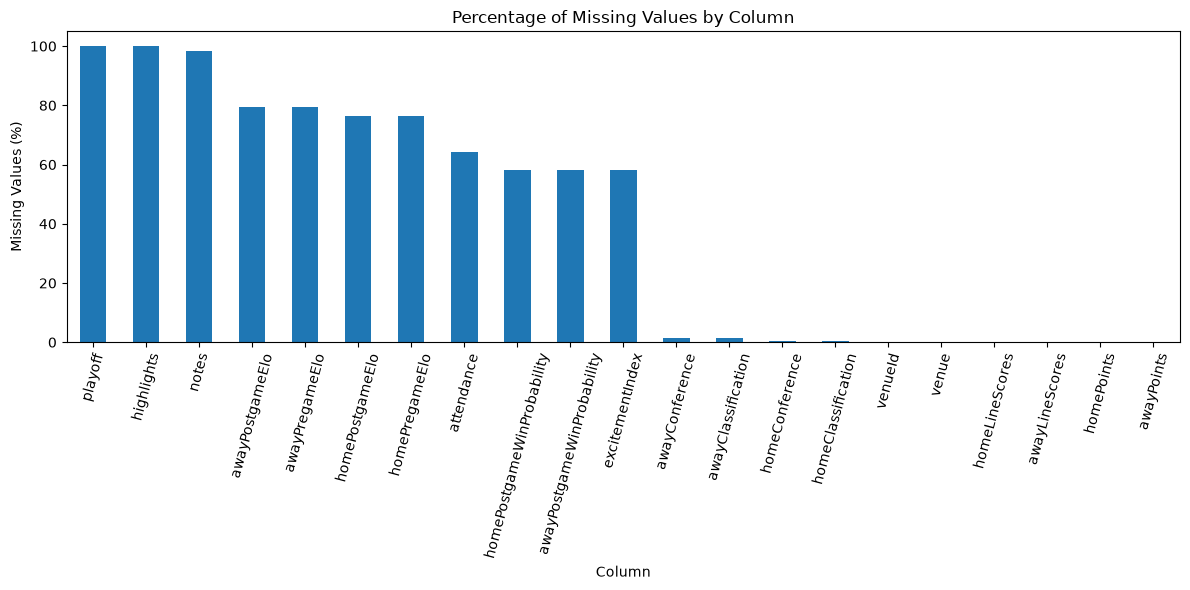

In [20]:
import matplotlib.pyplot as plt

# Visualize missing data percentages
missing_data["Missing Percentage"].plot(kind="bar", figsize=(12, 6))

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [21]:
# Examine attendance coverage by season
attendance_by_season = games_df.groupby("season")["attendance"].agg(
    Total_Games="size",
    Games_With_Attendance="count"
)

attendance_by_season["Missing_Attendance"] = (
    attendance_by_season["Total_Games"]
    - attendance_by_season["Games_With_Attendance"]
)

attendance_by_season["Attendance_Coverage_Percentage"] = (
    attendance_by_season["Games_With_Attendance"]
    / attendance_by_season["Total_Games"] * 100
).round(2)

attendance_by_season

,Total_Games,Games_With_Attendance,Missing_Attendance,Attendance_Coverage_Percentage
season,,,,
2023,3595,851,2744,23.67
2024,3747,1544,2203,41.21
2025,3745,1575,2170,42.06


In [22]:
# Examine attendance coverage by home-team classification
attendance_by_classification = games_df.groupby(
    "homeClassification",
    dropna=False
)["attendance"].agg(
    Total_Games="size",
    Games_With_Attendance="count"
)

attendance_by_classification["Missing_Attendance"] = (
    attendance_by_classification["Total_Games"]
    - attendance_by_classification["Games_With_Attendance"]
)

attendance_by_classification["Attendance_Coverage_Percentage"] = (
    attendance_by_classification["Games_With_Attendance"]
    / attendance_by_classification["Total_Games"] * 100
).round(2)

attendance_by_classification

,Total_Games,Games_With_Attendance,Missing_Attendance,Attendance_Coverage_Percentage
homeClassification,,,,
fbs,2630,2586,44,98.33
fcs,2157,1380,777,63.98
ii,2626,3,2623,0.11
iii,3619,1,3618,0.03
NaN,55,0,55,0.00


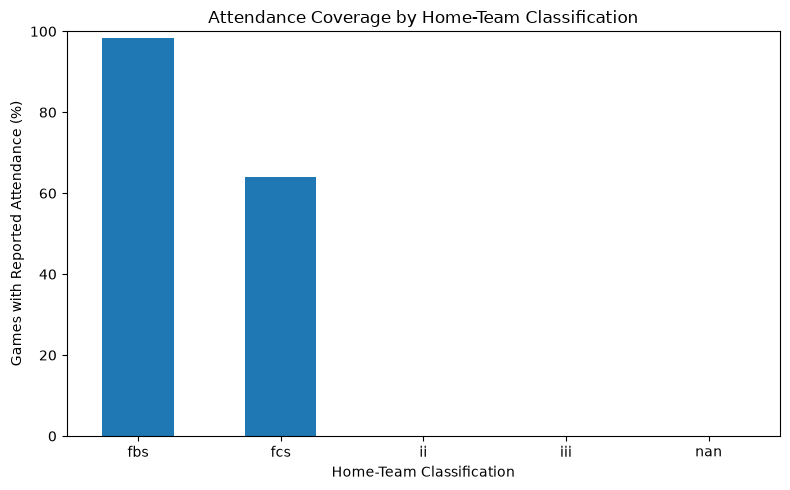

In [23]:
# Visualize attendance coverage by home-team classification
coverage_plot = attendance_by_classification.dropna().copy()

coverage_plot["Attendance_Coverage_Percentage"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Attendance Coverage by Home-Team Classification")
plt.xlabel("Home-Team Classification")
plt.ylabel("Games with Reported Attendance (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Missing Data Findings

The expanded dataset still contains several variables with substantial missing data. `playoff` and `highlights` are completely missing, while `notes` is missing for 98.20% of games. The Elo variables are missing for approximately 76–80% of observations, while postgame win probability and excitement index are missing for about 58% of games.

Attendance is missing for 7,117 of the 11,087 games (64.19%), leaving 3,970 games with reported attendance. However, the missing attendance values are not distributed evenly throughout the dataset.

Attendance coverage differs substantially by season. Only 23.67% of games in 2023 have reported attendance, compared with 41.21% in 2024 and 42.06% in 2025.

Attendance availability is also strongly associated with home-team classification. FBS home games have the most complete attendance data, with 2,586 of 2,630 games (98.33%) reporting attendance. FCS coverage is also substantial, with 1,380 of 2,157 games (63.98%) reporting attendance. In contrast, Division II and Division III games have almost no reported attendance.

This indicates that attendance missingness is highly structured rather than evenly distributed across games. Because the project focuses on stadium attendance, team classification and season should be considered when determining which observations are appropriate for later turnout analysis and modeling.

## 3. Data Quality and Consistency

In addition to missing values, the expanded game data is checked for duplicate records, game completion status, neutral-site games, and other structural characteristics that could affect later attendance analysis or modeling.

In [24]:
# Check for duplicate games
print("Duplicate rows:", games_df.duplicated().sum())
print("Duplicate game IDs:", games_df["id"].duplicated().sum())

print("\nCompleted games:")
print(games_df["completed"].value_counts(dropna=False))

print("\nNeutral-site games:")
print(games_df["neutralSite"].value_counts(dropna=False))

print("\nSeason types:")
print(games_df["seasonType"].value_counts(dropna=False))

Duplicate rows: 0
Duplicate game IDs: 0

Completed games:
completed
True     11075
False       12
Name: count, dtype: int64

Neutral-site games:
neutralSite
False    10748
True       339
Name: count, dtype: int64

Season types:
seasonType
regular    11087
Name: count, dtype: int64


In [25]:
# Examine team and venue coverage
print("Home team classifications:")
print(games_df["homeClassification"].value_counts(dropna=False))

print("\nAway team classifications:")
print(games_df["awayClassification"].value_counts(dropna=False))

print("\nNumber of unique home teams:", games_df["homeTeam"].nunique())
print("Number of unique venues:", games_df["venue"].nunique())

Home team classifications:
homeClassification
iii    3619
fbs    2630
ii     2626
fcs    2157
NaN      55
Name: count, dtype: int64

Away team classifications:
awayClassification
iii    3612
ii     2692
fcs    2356
fbs    2265
NaN     162
Name: count, dtype: int64

Number of unique home teams: 703
Number of unique venues: 731


### Data Quality Findings

No duplicate rows or duplicate game IDs were found in the expanded dataset, indicating that each game appears to be represented only once.

Most games are marked as completed, with 11,075 completed games and only 12 incomplete games. Because attendance represents actual game turnout, incomplete games may need to be excluded from later attendance and modeling analysis.

The dataset contains 339 neutral-site games and 10,748 non-neutral-site games. Neutral-site games may require special consideration when stadium capacity is incorporated because the listed home team may not be playing at its normal home stadium.

The dataset includes teams from FBS, FCS, Division II, and Division III, along with a small number of games with missing classifications. There are 703 unique home teams and 731 unique venues represented across the three seasons.

Overall, the game records appear structurally consistent, but game completion status, neutral-site status, classification, and missing venue information should be considered before constructing the final modeling dataset.

## 4. Attendance Distribution and Quality

Because attendance is central to the project's turnout prediction goal, reported attendance values are examined in greater detail. This includes descriptive statistics, checks for potentially invalid values, and the overall distribution of attendance across games.

In [26]:
# Focus only on games with reported attendance
attendance_data = games_df[games_df["attendance"].notna()].copy()

# Basic attendance statistics
print("Games with reported attendance:", len(attendance_data))
print("Minimum attendance:", attendance_data["attendance"].min())
print("Maximum attendance:", attendance_data["attendance"].max())
print("Mean attendance:", round(attendance_data["attendance"].mean(), 2))
print("Median attendance:", attendance_data["attendance"].median())

print("\nZero attendance values:",
      (attendance_data["attendance"] == 0).sum())

print("Negative attendance values:",
      (attendance_data["attendance"] < 0).sum())

print("\nAttendance descriptive statistics:")
display(attendance_data["attendance"].describe())

Games with reported attendance: 3970
Minimum attendance: 245.0
Maximum attendance: 111373.0
Mean attendance: 30107.36
Median attendance: 20178.5

Zero attendance values: 0
Negative attendance values: 0

Attendance descriptive statistics:


count      3970.000000
mean      30107.357935
std       27521.556804
min         245.000000
25%        8010.500000
50%       20178.500000
75%       47230.000000
max      111373.000000
Name: attendance, dtype: float64

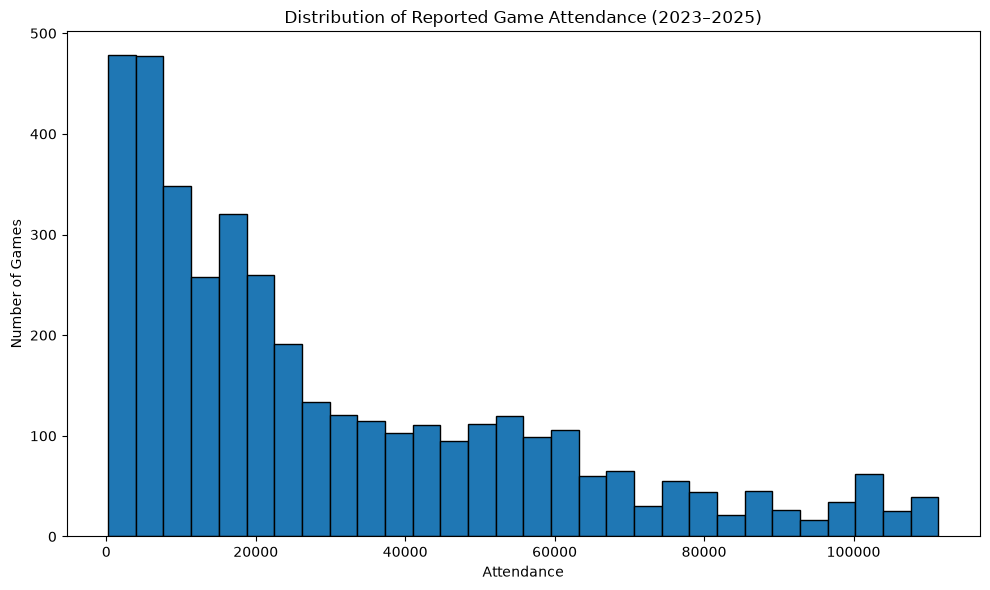

In [27]:
# Plot the distribution of reported attendance
plt.figure(figsize=(10, 6))

plt.hist(
    attendance_data["attendance"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Reported Game Attendance (2023–2025)")
plt.xlabel("Attendance")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

In [28]:
# Compare attendance statistics across seasons
attendance_by_season_stats = attendance_data.groupby("season")["attendance"].agg(
    Games_With_Attendance="count",
    Mean_Attendance="mean",
    Median_Attendance="median",
    Minimum_Attendance="min",
    Maximum_Attendance="max"
).round(2)

attendance_by_season_stats

,Games_With_Attendance,Mean_Attendance,Median_Attendance,Minimum_Attendance,Maximum_Attendance
season,,,,,
2023,851,42216.17,36447.0,5349.0,110856.0
2024,1544,26773.10,16399.5,453.0,111170.0
2025,1575,26833.39,16715.0,245.0,111373.0


<Figure size 900x600 with 0 Axes>

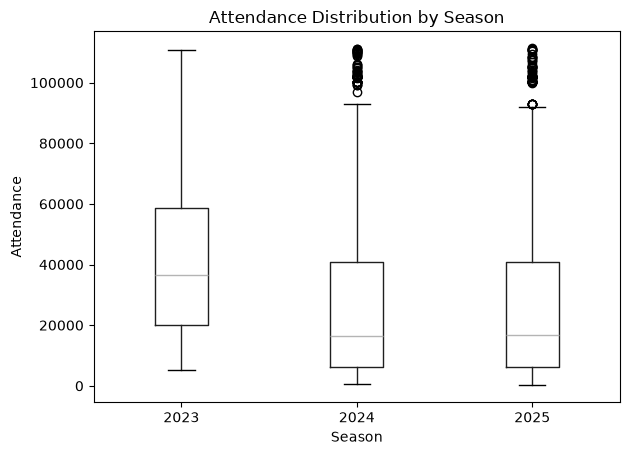

In [29]:
# Compare attendance distributions across the three seasons
plt.figure(figsize=(9, 6))

attendance_data.boxplot(
    column="attendance",
    by="season",
    grid=False
)

plt.title("Attendance Distribution by Season")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Attendance")
plt.tight_layout()
plt.show()

In [30]:
# Look at the games with the highest reported attendance
highest_attendance = attendance_data[
    ["season", "week", "homeTeam", "awayTeam",
     "homeClassification", "venue", "attendance"]
].sort_values("attendance", ascending=False).head(15)

highest_attendance

,season,week,homeTeam,awayTeam,homeClassification,venue,attendance
10974,2025,14,Michigan,Ohio State,fbs,Michigan Stadium,111373.0
3850,2024,2,Michigan,Texas,fbs,Michigan Stadium,111170.0
8751,2025,6,Michigan,Wisconsin,fbs,Michigan Stadium,111070.0
6198,2024,10,Penn State,Ohio State,fbs,Beaver Stadium,111030.0
8696,2025,5,Penn State,Oregon,fbs,Beaver Stadium,111015.0
3106,2023,11,Penn State,Michigan,fbs,Beaver Stadium,110856.0
6140,2024,9,Michigan,Michigan State,fbs,Michigan Stadium,110849.0
1237,2023,4,Penn State,Iowa,fbs,Beaver Stadium,110830.0
307,2023,1,Penn State,West Virginia,fbs,Beaver Stadium,110747.0
7876,2025,3,Michigan,Central Michigan,fbs,Michigan Stadium,110740.0


In [31]:
# Look at the games with the lowest reported attendance
lowest_attendance = attendance_data[
    ["season", "week", "homeTeam", "awayTeam",
     "homeClassification", "venue", "attendance"]
].sort_values("attendance").head(15)

lowest_attendance

,season,week,homeTeam,awayTeam,homeClassification,venue,attendance
8191,2025,4,Morgan State,Central State,fcs,Hughes Stadium,245.0
10238,2025,11,Long Island University,Duquesne,fcs,Bethpage Federal Credit Union Stadium,400.0
5870,2024,9,Long Island University,Central Connecticut,fcs,Bethpage Federal Credit Union Stadium,453.0
3622,2024,1,Wheeling,Mercyhurst,ii,Bishop Schmitt Field,500.0
5426,2024,7,Norfolk State,Towson,fcs,"William Dick"""" Price Stadium""""",501.0
7381,2025,1,Samford,West Georgia,fcs,Seibert Stadium,506.0
6467,2024,11,Mercyhurst,Lincoln (CA),fcs,Saxon Stadium,540.0
8098,2025,3,Western Illinois,Valparaiso,fcs,Hanson Field,572.0
6797,2024,12,Long Island University,Saint Francis,fcs,Bethpage Federal Credit Union Stadium,684.0
7098,2024,13,Bucknell,Colgate,fcs,Christy Mathewson-Memorial Stadium,762.0


### Attendance Distribution Findings

There are 3,970 games with reported attendance across the three seasons. Reported attendance ranges from 245 to 111,373 spectators, with no zero or negative attendance values identified. Inspection of games at the highest and lowest ends of the distribution did not reveal obvious invalid attendance records.

The overall mean attendance is approximately 30,107, while the median is approximately 20,179. The substantially higher mean indicates that the attendance distribution is right-skewed, with a smaller number of very highly attended games increasing the average.

Attendance patterns also differ across seasons. In 2023, games with reported attendance had a mean of approximately 42,216 and a median of 36,447. In 2024 and 2025, the means were approximately 26,773 and 26,833, while the medians were approximately 16,400 and 16,715.

However, these differences should not be interpreted as a direct decline in attendance. Attendance coverage changed substantially across seasons, particularly because the expanded data includes considerably more FCS attendance observations in 2024 and 2025. Therefore, differences in the composition of games with reported attendance may contribute to the lower overall attendance values in those seasons.

## 5. Attendance Patterns by Week and Season

Attendance is examined across the regular-season schedule to identify potential relationships between the timing of a game and stadium attendance. Because the dataset now covers three seasons, weekly attendance patterns can also be compared across years.

In [32]:
# Calculate attendance statistics by week
attendance_by_week = attendance_data.groupby("week")["attendance"].agg(
    Games="count",
    Mean_Attendance="mean",
    Median_Attendance="median"
).round(2)

attendance_by_week

,Games,Mean_Attendance,Median_Attendance
week,,,
1,359,34838.74,26973.0
2,326,35734.35,27056.0
3,297,32945.67,23537.0
4,298,31053.77,20146.0
5,263,28827.58,21227.0
6,254,28543.25,17844.0
7,267,27794.13,18443.0
8,270,27804.12,19077.0
9,274,27785.30,17785.5


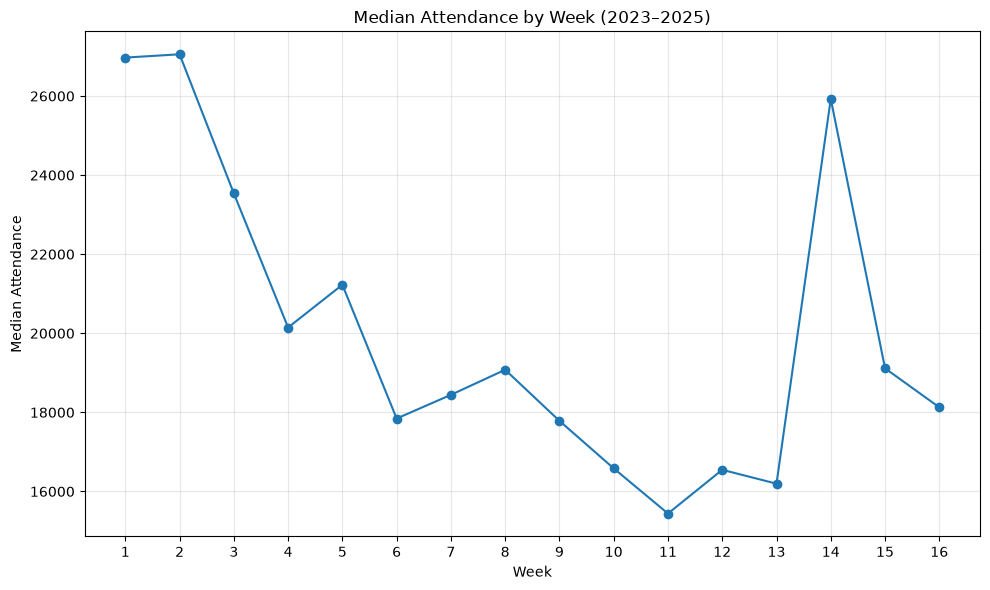

In [33]:
# Plot median attendance by week
weekly_median = attendance_data.groupby("week")["attendance"].median()

plt.figure(figsize=(10, 6))
plt.plot(
    weekly_median.index,
    weekly_median.values,
    marker="o"
)

plt.title("Median Attendance by Week (2023–2025)")
plt.xlabel("Week")
plt.ylabel("Median Attendance")
plt.xticks(weekly_median.index)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

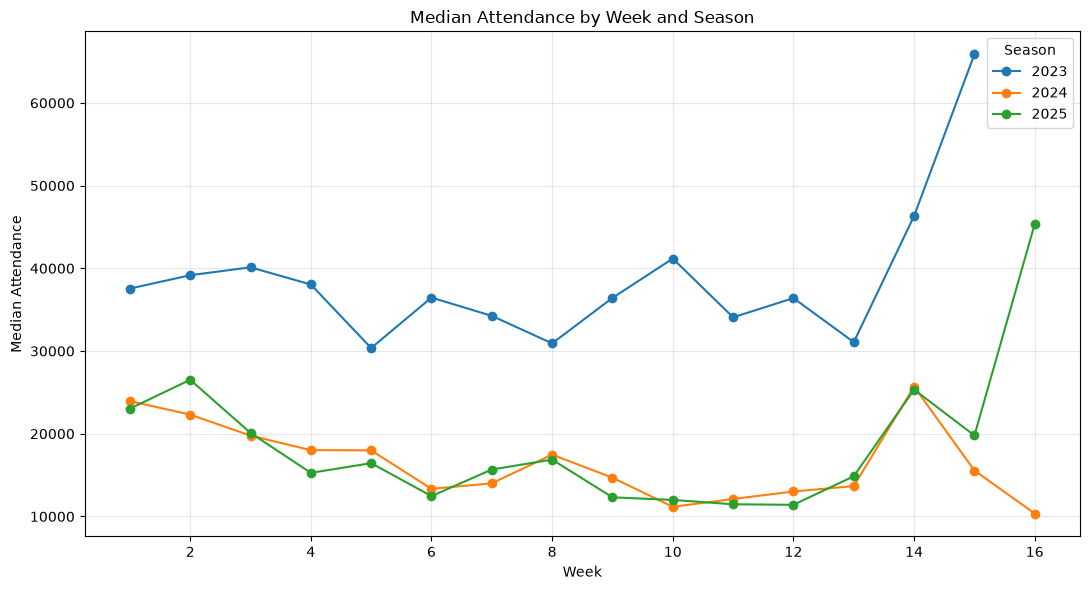

In [34]:
# Compare weekly median attendance across seasons
weekly_by_season = attendance_data.groupby(
    ["season", "week"]
)["attendance"].median().unstack(level=0)

weekly_by_season.plot(
    figsize=(11, 6),
    marker="o"
)

plt.title("Median Attendance by Week and Season")
plt.xlabel("Week")
plt.ylabel("Median Attendance")
plt.legend(title="Season")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Weekly Attendance Findings

Across all three seasons, median attendance is generally higher during the opening weeks of the season and lower during many of the middle and later weeks. Median attendance is approximately 27,000 in Weeks 1 and 2, compared with roughly 15,000–19,000 during several later weeks.

Week 14 shows an increase in median attendance to approximately 25,930. However, attendance patterns near the end of the season should be interpreted cautiously because the number of games decreases substantially. Only 37 games with reported attendance are available in Week 15 and 7 in Week 16, making these estimates more sensitive to individual games.

The season-level comparison also shows that reported attendance for 2023 is consistently higher than for 2024 and 2025 across most weeks. This should not necessarily be interpreted as a decline in college football attendance. Earlier analysis showed that attendance coverage differs substantially across seasons and classifications, with considerably more FCS attendance observations available in 2024 and 2025. Therefore, changes in the composition of games with reported attendance likely contribute to the differences between seasons.

Overall, week may contain useful information for predicting turnout, but its relationship with attendance should be considered alongside season, team classification, stadium capacity, and other game characteristics.

## 6. Attendance Patterns by Conference

Attendance is compared across home-team conferences to determine whether conference affiliation is associated with differences in game attendance. Because FBS games have the most complete attendance coverage, the initial conference comparison focuses on FBS home teams.

In [35]:
# Keep FBS home games with reported attendance
fbs_attendance = attendance_data[
    attendance_data["homeClassification"] == "fbs"
].copy()

# Calculate attendance statistics by home conference
conference_attendance = fbs_attendance.groupby(
    "homeConference"
)["attendance"].agg(
    Games="count",
    Mean_Attendance="mean",
    Median_Attendance="median"
).round(2)

# Sort from highest to lowest median attendance
conference_attendance = conference_attendance.sort_values(
    "Median_Attendance",
    ascending=False
)

conference_attendance

,Games,Mean_Attendance,Median_Attendance
homeConference,,,
SEC,333,78575.51,83329.0
Big Ten,339,65806.04,61441.0
Big 12,300,50317.85,50532.5
ACC,324,47956.87,48329.0
Pac-12,105,44144.98,44141.0
FBS Independents,59,41636.66,30122.0
Mountain West,224,24611.58,23082.0
American Athletic,257,24300.86,22489.0
Sun Belt,251,21245.43,20183.0


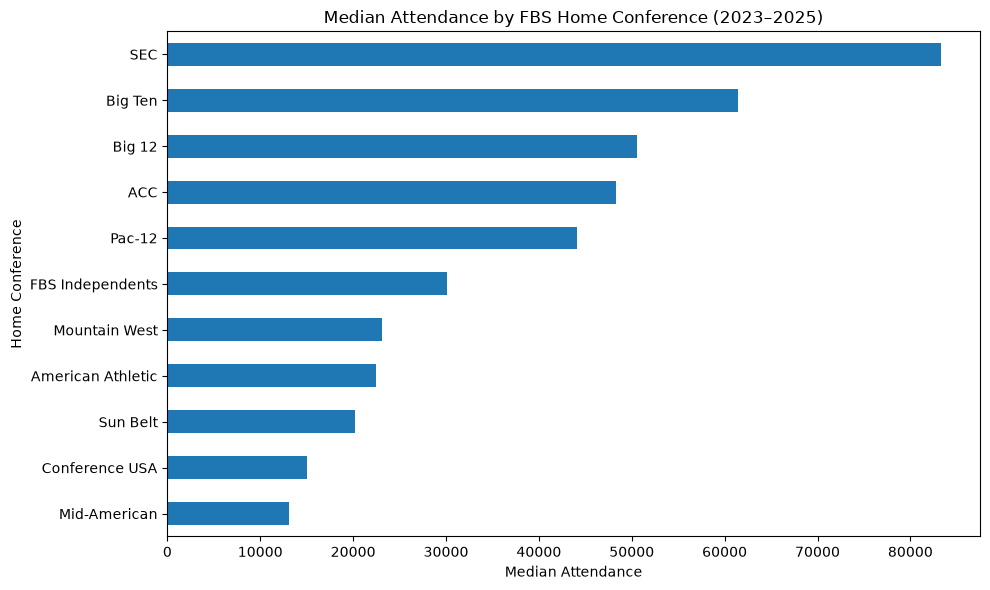

In [36]:
# Visualize median attendance by FBS home conference
plt.figure(figsize=(10, 6))

conference_attendance["Median_Attendance"].sort_values().plot(
    kind="barh"
)

plt.title("Median Attendance by FBS Home Conference (2023–2025)")
plt.xlabel("Median Attendance")
plt.ylabel("Home Conference")
plt.tight_layout()
plt.show()

### Conference Attendance Findings

Attendance differs substantially across FBS home-team conferences. The SEC has the highest median attendance at 83,329 spectators, followed by the Big Ten at 61,441 and the Big 12 at approximately 50,533. The Mid-American Conference has the lowest median attendance in the FBS data at 13,108.

These differences suggest that conference affiliation is associated with substantial variation in raw game attendance. However, raw attendance alone does not indicate how full a stadium is. Conferences containing teams with larger stadiums may naturally have higher attendance even if the proportion of available seats filled is similar.

For this reason, stadium capacity should be incorporated before interpreting these differences as differences in turnout. Comparing attendance relative to stadium capacity will provide a more meaningful measure of stadium turnout for the project's prediction target.

## 7. Stadium Data and Capacity

The expanded project data includes separate stadium datasets containing capacity and location information. Because raw attendance can be strongly influenced by stadium size, these datasets are explored to determine whether stadium capacity can be reliably connected to the game records and used to calculate attendance relative to available capacity.

In [37]:
# Examine stadium dataset completeness
stadium_summary = pd.DataFrame({
    "Dataset": ["FBS Stadiums", "FCS Stadiums", "Geocoded Stadiums"],
    "Rows": [
        len(fbs_stadiums_df),
        len(fcs_stadiums_df),
        len(geocoded_stad_df)
    ],
    "Unique Stadiums": [
        fbs_stadiums_df["stadium"].nunique(),
        fcs_stadiums_df["stadium"].nunique(),
        geocoded_stad_df["stadium"].nunique()
    ],
    "Missing Capacity": [
        fbs_stadiums_df["capacity"].isna().sum(),
        fcs_stadiums_df["capacity"].isna().sum(),
        geocoded_stad_df["capacity"].isna().sum()
    ],
    "Missing Team": [
        fbs_stadiums_df["team"].isna().sum(),
        fcs_stadiums_df["team"].isna().sum(),
        geocoded_stad_df["team"].isna().sum()
    ]
})

stadium_summary

,Dataset,Rows,Unique Stadiums,Missing Capacity,Missing Team
0,FBS Stadiums,250,124,121,121
1,FCS Stadiums,152,123,27,27
2,Geocoded Stadiums,253,241,0,0


In [38]:
# Examine capacity values in each stadium dataset
print("FBS Capacity:")
display(fbs_stadiums_df["capacity"].describe())

print("\nFCS Capacity:")
display(fcs_stadiums_df["capacity"].describe())

print("\nGeocoded Stadium Capacity:")
display(geocoded_stad_df["capacity"].describe())

FBS Capacity:


count        129
unique       127
top       30,000
freq           3
Name: capacity, dtype: object


FCS Capacity:


count        125
unique       115
top       10,000
freq           4
Name: capacity, dtype: object


Geocoded Stadium Capacity:


count       253.000000
mean      33200.466403
std       25904.041476
min        2200.000000
25%       12283.000000
50%       25200.000000
75%       50000.000000
max      107601.000000
Name: capacity, dtype: float64

In [39]:
# Check for duplicate teams and stadiums in the geocoded stadium data
print("Total rows:", len(geocoded_stad_df))
print("Unique teams:", geocoded_stad_df["team"].nunique())
print("Duplicate team names:", geocoded_stad_df["team"].duplicated().sum())

print("\nUnique stadiums:", geocoded_stad_df["stadium"].nunique())
print("Duplicate stadium names:", geocoded_stad_df["stadium"].duplicated().sum())

Total rows: 253
Unique teams: 253
Duplicate team names: 0

Unique stadiums: 241
Duplicate stadium names: 12


In [40]:
# Display duplicated team names, if any
geocoded_stad_df[
    geocoded_stad_df["team"].duplicated(keep=False)
].sort_values("team")

,stadium,city,state,team,conference,capacity,built,expanded,div,latitude,longitude


In [41]:
# Check how well game home-team names match stadium team names
game_home_teams = set(games_df["homeTeam"].dropna().unique())
stadium_teams = set(geocoded_stad_df["team"].dropna().unique())

matched_teams = game_home_teams.intersection(stadium_teams)

print("Unique home teams in game data:", len(game_home_teams))
print("Unique teams in geocoded stadium data:", len(stadium_teams))
print("Exact team-name matches:", len(matched_teams))

# More relevant: match coverage among games with reported attendance
attendance_team_match = attendance_data["homeTeam"].isin(stadium_teams)

print("\nGames with reported attendance:", len(attendance_data))
print("Attendance games with stadium team match:", attendance_team_match.sum())
print(
    "Match percentage:",
    round(attendance_team_match.mean() * 100, 2),
    "%"
)

Unique home teams in game data: 703
Unique teams in geocoded stadium data: 253
Exact team-name matches: 117

Games with reported attendance: 3970
Attendance games with stadium team match: 2257
Match percentage: 56.85 %


In [42]:
# Check stadium matching separately for FBS and FCS attendance games
match_by_classification = attendance_data.copy()

match_by_classification["stadium_team_match"] = (
    match_by_classification["homeTeam"].isin(stadium_teams)
)

match_summary = match_by_classification.groupby(
    "homeClassification"
)["stadium_team_match"].agg(
    Total_Games="count",
    Matched_Games="sum"
)

match_summary["Unmatched_Games"] = (
    match_summary["Total_Games"]
    - match_summary["Matched_Games"]
)

match_summary["Match_Percentage"] = (
    match_summary["Matched_Games"]
    / match_summary["Total_Games"] * 100
).round(2)

match_summary

,Total_Games,Matched_Games,Unmatched_Games,Match_Percentage
homeClassification,,,,
fbs,2586,2232,354,86.31
fcs,1380,25,1355,1.81
ii,3,0,3,0.00
iii,1,0,1,0.00


In [43]:
# Identify FBS and FCS home teams with attendance data
# that do not exactly match a team in the stadium dataset
unmatched_teams = (
    attendance_data[
        (attendance_data["homeClassification"].isin(["fbs", "fcs"])) &
        (~attendance_data["homeTeam"].isin(stadium_teams))
    ]
    .groupby(["homeClassification", "homeTeam"])
    .size()
    .reset_index(name="Games")
    .sort_values(["homeClassification", "Games"], ascending=[True, False])
)

unmatched_teams

,homeClassification,homeTeam,Games
4,fbs,Hawai'i,21
13,fbs,Ole Miss,21
8,fbs,Liberty,20
5,fbs,Jacksonville State,19
9,fbs,Louisiana,19
...,...,...,...
55,fcs,Fordham,6
95,fcs,North Carolina Central,6
112,fcs,Saint Francis,6
82,fcs,Missouri State,5


### Stadium Matching Findings

The geocoded stadium dataset contains complete team and capacity information for 253 teams. However, exact team-name matching between the game and stadium datasets does not provide equal coverage across classifications.

Among FBS games with reported attendance, 2,232 of 2,586 games (86.31%) match a team in the geocoded stadium dataset. In contrast, only 25 of 1,380 FCS attendance records (1.81%) match. Therefore, the relatively low overall match rate of 56.85% is primarily caused by limited FCS coverage rather than a general inability to connect game and stadium records.

Because FCS stadium coverage is extremely limited, calculating turnout rates from the geocoded stadium data would produce a highly incomplete FCS sample. FBS games provide substantially stronger coverage, although 354 FBS attendance records still do not have an exact team-name match and should be investigated before turnout is calculated.

In [44]:
# List unique unmatched FBS teams
unmatched_fbs_teams = sorted(
    attendance_data.loc[
        (attendance_data["homeClassification"] == "fbs") &
        (~attendance_data["homeTeam"].isin(stadium_teams)),
        "homeTeam"
    ].unique()
)

print("Number of unmatched FBS teams:", len(unmatched_fbs_teams))
print("\nUnmatched FBS teams:")
for team in unmatched_fbs_teams:
    print(team)

Number of unmatched FBS teams: 21

Unmatched FBS teams:
App State
Coastal Carolina
Delaware
Florida International
Hawai'i
Jacksonville State
James Madison
Kennesaw State
Liberty
Louisiana
Massachusetts
Missouri State
Northern Illinois
Ole Miss
Sam Houston
San José State
South Florida
UAB
UConn
UL Monroe
USC


In [45]:
# Search stadium team names for possible matches to unmatched FBS teams
for team in unmatched_fbs_teams:
    first_word = team.split()[0]

    possible_matches = geocoded_stad_df[
        geocoded_stad_df["team"].str.contains(
            first_word,
            case=False,
            na=False,
            regex=False
        )
    ]["team"].tolist()

    print(f"{team}: {possible_matches}")

App State: ['Appalachian State']
Coastal Carolina: ['Coastal Carolina Chanticleers']
Delaware: ["Delaware Fightin' Blue Hens", 'Delaware State Hornets']
Florida International: ['Florida', 'Florida State', 'Florida Atlantic', 'Florida A&M Rattlers']
Hawai'i: []
Jacksonville State: ['Jacksonville State Gamecocks', 'Jacksonville Dolphins']
James Madison: ['James Madison Dukes']
Kennesaw State: ['Kennesaw State Owls']
Liberty: ['Liberty Flames']
Louisiana: ['Louisiana-Lafayette', 'Louisiana Tech', 'Louisiana-Monroe', 'Southeastern Louisiana Lions']
Massachusetts: []
Missouri State: ['Missouri', 'Missouri State Bears', 'Southeast Missouri State Redhawks']
Northern Illinois: ['Northern Iowa Panthers', 'Northern Arizona Lumberjacks', 'Northern Colorado Bears']
Ole Miss: ['Toledo']
Sam Houston: ['Sam Houston State Bearkats', 'Samford Bulldogs']
San José State: ['San Diego State', 'San Jose State', 'San Diego Toreros']
South Florida: ['Southern California', 'South Carolina', 'Southern Miss', 'S

In [46]:
# Map clearly equivalent FBS team names between the game and stadium datasets
team_name_mapping = {
    "App State": "Appalachian State",
    "Coastal Carolina": "Coastal Carolina Chanticleers",
    "Jacksonville State": "Jacksonville State Gamecocks",
    "James Madison": "James Madison Dukes",
    "Kennesaw State": "Kennesaw State Owls",
    "Liberty": "Liberty Flames",
    "Louisiana": "Louisiana-Lafayette",
    "Missouri State": "Missouri State Bears",
    "Sam Houston": "Sam Houston State Bearkats",
    "San José State": "San Jose State"
}

# Create a matching column without changing the original homeTeam column
attendance_data["homeTeam_match"] = attendance_data["homeTeam"].replace(
    team_name_mapping
)

# Recheck matching coverage
attendance_data["stadium_team_match"] = (
    attendance_data["homeTeam_match"].isin(stadium_teams)
)

fbs_after_mapping = attendance_data[
    attendance_data["homeClassification"] == "fbs"
]

print("FBS attendance games:", len(fbs_after_mapping))
print(
    "FBS games matched to stadium:",
    fbs_after_mapping["stadium_team_match"].sum()
)

print(
    "FBS match percentage:",
    round(fbs_after_mapping["stadium_team_match"].mean() * 100, 2),
    "%"
)

FBS attendance games: 2586
FBS games matched to stadium: 2395
FBS match percentage: 92.61 %


After applying a conservative mapping for clearly equivalent team names, FBS stadium matching improved from 86.31% to 92.61%. Of the 2,586 FBS games with reported attendance, 2,395 can now be connected to a stadium record. The remaining unmatched games are retained rather than assigned an uncertain stadium match.

In [47]:
# Keep the stadium variables needed for turnout analysis
stadium_capacity = geocoded_stad_df[
    ["team", "stadium", "capacity", "latitude", "longitude"]
].copy()

# Merge stadium information onto FBS games with reported attendance
fbs_turnout = fbs_after_mapping.merge(
    stadium_capacity,
    left_on="homeTeam_match",
    right_on="team",
    how="left"
)

print("FBS games with attendance:", len(fbs_turnout))
print("Games with matched capacity:", fbs_turnout["capacity"].notna().sum())
print("Games missing capacity:", fbs_turnout["capacity"].isna().sum())

print(
    "Capacity coverage:",
    round(fbs_turnout["capacity"].notna().mean() * 100, 2),
    "%"
)

FBS games with attendance: 2586
Games with matched capacity: 2395
Games missing capacity: 191
Capacity coverage: 92.61 %


In [48]:
# Calculate attendance as a proportion of stadium capacity
fbs_turnout["turnout_rate"] = (
    fbs_turnout["attendance"] / fbs_turnout["capacity"]
)

# Keep games where capacity is available
turnout_data = fbs_turnout[
    fbs_turnout["capacity"].notna()
].copy()

print("Games available for turnout analysis:", len(turnout_data))

print("\nTurnout rate descriptive statistics:")
display(turnout_data["turnout_rate"].describe())

print(
    "\nGames with attendance greater than listed capacity:",
    (turnout_data["turnout_rate"] > 1).sum()
)

print(
    "Games at or below listed capacity:",
    (turnout_data["turnout_rate"] <= 1).sum()
)

Games available for turnout analysis: 2395

Turnout rate descriptive statistics:


count    2395.000000
mean        0.810137
std         0.271208
min         0.048727
25%         0.632400
50%         0.866884
75%         0.990926
max         2.411222
Name: turnout_rate, dtype: float64


Games with attendance greater than listed capacity: 459
Games at or below listed capacity: 1936


In [49]:
# Examine games where reported attendance exceeds listed stadium capacity
over_capacity = turnout_data[
    turnout_data["turnout_rate"] > 1
][[
    "season",
    "week",
    "homeTeam",
    "awayTeam",
    "venue",
    "stadium",
    "neutralSite",
    "attendance",
    "capacity",
    "turnout_rate"
]].copy()

over_capacity["turnout_rate"] = over_capacity["turnout_rate"].round(3)

over_capacity.sort_values(
    "turnout_rate",
    ascending=False
).head(25)

,season,week,homeTeam,awayTeam,venue,stadium,neutralSite,attendance,capacity,turnout_rate
1872,2025,2,Coastal Carolina,Charleston Southern,Brooks Stadium (SC),Brooks Stadium,False,22217.0,9214.0,2.411
1099,2024,4,Coastal Carolina,Virginia,Brooks Stadium (SC),Brooks Stadium,False,22104.0,9214.0,2.399
1938,2025,3,Coastal Carolina,East Carolina,Brooks Stadium (SC),Brooks Stadium,False,21634.0,9214.0,2.348
1729,2025,1,Charlotte,App State,Bank of America Stadium,Jerry Richardson Stadium,True,35718.0,15314.0,2.332
569,2023,9,Coastal Carolina,Marshall,Brooks Stadium (SC),Brooks Stadium,False,21324.0,9214.0,2.314
1371,2024,9,Navy,Notre Dame,MetLife Stadium,Navy–Marine Corps Memorial Stadium,True,76112.0,34000.0,2.239
1465,2024,11,Coastal Carolina,App State,Brooks Stadium (SC),Brooks Stadium,False,19415.0,9214.0,2.107
1002,2024,2,Coastal Carolina,William & Mary,Brooks Stadium (SC),Brooks Stadium,False,19294.0,9214.0,2.094
2585,2025,16,Navy,Army,M&T Bank Stadium,Navy–Marine Corps Memorial Stadium,True,70936.0,34000.0,2.086
2373,2025,11,Coastal Carolina,Georgia State,Brooks Stadium (SC),Brooks Stadium,False,18878.0,9214.0,2.049


In [50]:
# Check whether over-capacity records are associated with neutral-site games
print("Games above listed capacity:", len(over_capacity))

print(
    "Neutral-site games above capacity:",
    over_capacity["neutralSite"].sum()
)

print(
    "Non-neutral-site games above capacity:",
    (~over_capacity["neutralSite"]).sum()
)

print(
    "\nPercentage of over-capacity games that are neutral-site:",
    round(over_capacity["neutralSite"].mean() * 100, 2),
    "%"
)

Games above listed capacity: 459
Neutral-site games above capacity: 19
Non-neutral-site games above capacity: 440

Percentage of over-capacity games that are neutral-site: 4.14 %


In [51]:
# Examine different levels of attendance relative to capacity
print("Turnout > 100%:",
      (turnout_data["turnout_rate"] > 1.00).sum())

print("Turnout > 110%:",
      (turnout_data["turnout_rate"] > 1.10).sum())

print("Turnout > 125%:",
      (turnout_data["turnout_rate"] > 1.25).sum())

print("Turnout > 150%:",
      (turnout_data["turnout_rate"] > 1.50).sum())

print("Turnout > 200%:",
      (turnout_data["turnout_rate"] > 2.00).sum())

Turnout > 100%: 459
Turnout > 110%: 109
Turnout > 125%: 57
Turnout > 150%: 30
Turnout > 200%: 11


### Capacity and Turnout Data Quality

After matching stadium capacity to FBS games, capacity information is available for 2,395 of the 2,586 FBS games with reported attendance (92.61%). Initial turnout rate was calculated as reported attendance divided by listed stadium capacity.

The median turnout rate is approximately 86.69%, while the mean is approximately 81.01%. However, 459 games have reported attendance greater than the listed stadium capacity. Most of these cases are only moderately above capacity: 109 games exceed 110% of listed capacity, 57 exceed 125%, and 30 exceed 150%.

Neutral-site games do not explain most of these observations. Only 19 of the 459 games above listed capacity are neutral-site games. Inspection of the largest turnout ratios also reveals repeated cases in which attendance appears inconsistent with the capacity value assigned by the stadium dataset. For example, multiple Coastal Carolina home games at Brooks Stadium report attendance substantially above the 9,214 capacity contained in the stadium data.

These findings indicate that stadium capacity should undergo additional validation before turnout rate is used to define the project's high- versus low-turnout target. Games exceeding listed capacity should not automatically be removed because the inconsistency may result from stadium capacity data rather than invalid attendance records.

In [52]:
# Identify teams with the most games above listed stadium capacity
over_capacity_by_team = (
    turnout_data[turnout_data["turnout_rate"] > 1]
    .groupby(["homeTeam", "stadium", "capacity"])
    .agg(
        Games_Above_Capacity=("turnout_rate", "size"),
        Max_Attendance=("attendance", "max"),
        Max_Turnout_Rate=("turnout_rate", "max")
    )
    .reset_index()
    .sort_values("Games_Above_Capacity", ascending=False)
)

over_capacity_by_team["Max_Turnout_Rate"] = (
    over_capacity_by_team["Max_Turnout_Rate"].round(3)
)

over_capacity_by_team.head(20)

,homeTeam,stadium,capacity,Games_Above_Capacity,Max_Attendance,Max_Turnout_Rate
33,Michigan,Michigan Stadium,107601.0,21,111373.0,1.035
4,Auburn,Jordan–Hare Stadium,87451.0,21,88043.0,1.007
44,Oklahoma,Gaylord Family Oklahoma Memorial Stadium,82112.0,21,92100.0,1.122
46,Oregon,Autzen Stadium,54000.0,20,67469.0,1.249
63,Utah,Rice-Eccles Stadium,45017.0,19,54383.0,1.208
11,Coastal Carolina,Brooks Stadium,9214.0,18,22217.0,2.411
56,Texas,Darrell K Royal–Texas Memorial Stadium,100119.0,17,105215.0,1.051
25,Kansas State,Bill Snyder Family Football Stadium,50000.0,17,53013.0,1.060
15,Florida,Ben Hill Griffin Stadium,88548.0,17,90751.0,1.025
1,App State,Kidd Brewer Stadium,24050.0,16,40168.0,1.670


In [53]:
# Compare the listed stadium capacity with attendance patterns for each team
team_capacity_check = (
    turnout_data
    .groupby(["homeTeam", "stadium", "capacity"])
    .agg(
        Games=("attendance", "count"),
        Median_Attendance=("attendance", "median"),
        Max_Attendance=("attendance", "max")
    )
    .reset_index()
)

team_capacity_check["Median_Attendance_to_Capacity"] = (
    team_capacity_check["Median_Attendance"] /
    team_capacity_check["capacity"]
).round(3)

team_capacity_check["Max_Attendance_to_Capacity"] = (
    team_capacity_check["Max_Attendance"] /
    team_capacity_check["capacity"]
).round(3)

team_capacity_check.sort_values(
    "Max_Attendance_to_Capacity",
    ascending=False
).head(20)

,homeTeam,stadium,capacity,Games,Median_Attendance,Max_Attendance,Median_Attendance_to_Capacity,Max_Attendance_to_Capacity
22,Coastal Carolina,Brooks Stadium,9214.0,18,17964.0,22217.0,1.950,2.411
19,Charlotte,Jerry Richardson Stadium,15314.0,18,14014.0,35718.0,0.915,2.332
66,Navy,Navy–Marine Corps Memorial Stadium,34000.0,19,30014.0,76112.0,0.883,2.239
51,Louisiana Tech,Joe Aillet Stadium,30600.0,18,15733.5,60229.0,0.514,1.968
88,Sam Houston,Bowers Stadium,14000.0,16,7343.0,27225.0,0.524,1.945
20,Cincinnati,Nippert Stadium,40000.0,21,38007.0,72884.0,0.950,1.822
8,Army,Michie Stadium,38000.0,20,28575.5,65878.0,0.752,1.734
87,SMU,Gerald J. Ford Stadium,32000.0,20,32878.5,53808.0,1.027,1.682
3,App State,Kidd Brewer Stadium,24050.0,17,34057.0,40168.0,1.416,1.670
68,Nevada,Mackay Stadium,30000.0,18,17418.5,44182.0,0.581,1.473


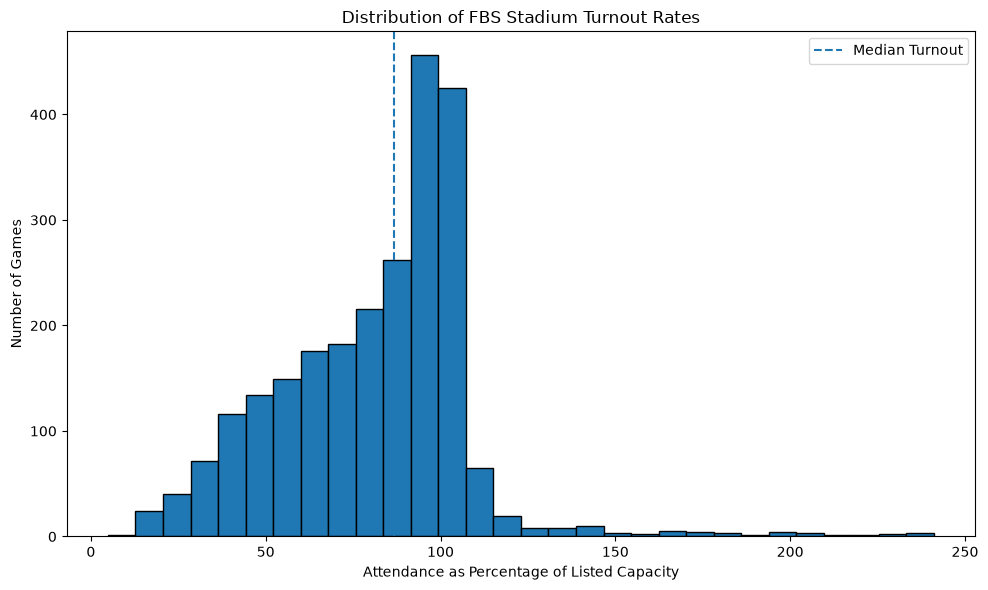

In [54]:
# Visualize the initial turnout-rate distribution
plt.figure(figsize=(10, 6))

plt.hist(turnout_data["turnout_rate"] * 100, bins=30, edgecolor="black")

plt.axvline(
    turnout_data["turnout_rate"].median() * 100,
    linestyle="--",
    label="Median Turnout"
)

plt.title("Distribution of FBS Stadium Turnout Rates")
plt.xlabel("Attendance as Percentage of Listed Capacity")
plt.ylabel("Number of Games")
plt.legend()

plt.tight_layout()
plt.show()

### Stadium and Capacity Findings

The stadium datasets were examined to determine whether stadium capacity could be incorporated into the attendance analysis. The geocoded stadium dataset was the most complete source, containing capacity and team information for all 253 records.

Initial exact team-name matching connected 86.31% of FBS games with reported attendance to a stadium. After accounting for several clear naming differences between the game and stadium datasets, the FBS match rate increased to 92.61%, providing capacity information for 2,395 of the 2,586 FBS games with reported attendance.

Using these matched records, an initial turnout rate was calculated as attendance divided by listed stadium capacity. The median turnout rate was approximately 86.7%, while the mean was approximately 81.0%.

The analysis also identified some inconsistencies between reported attendance and listed stadium capacity. A total of 459 games had attendance above the listed capacity, although most were only moderately above capacity. Inspection also showed that some larger differences may result from capacity-data inconsistencies or games played at venues other than a team's normal home stadium.

Overall, stadium capacity provides useful context that raw attendance alone cannot capture. However, the capacity data should be validated during later data cleaning before turnout rate is used to construct the final high-versus-low turnout target.

## 8. Considerations for Defining High and Low Turnout

The project's prediction target will ultimately classify games as having high or low stadium turnout relative to capacity. The initial analysis shows that stadium capacity provides a more meaningful basis for turnout than raw attendance alone because stadium sizes vary substantially across teams.

For the 2,395 FBS games with both reported attendance and matched stadium capacity, the median initial turnout rate is approximately 86.7% of listed capacity. This suggests that turnout rate could be used to construct the eventual classification target.

However, the EDA also identified inconsistencies between some reported attendance values and listed stadium capacities, including games with attendance above 100% of listed capacity. Therefore, the final high/low turnout threshold should be selected after the capacity data has been validated during the data-cleaning and feature-engineering stage.

At this stage, the EDA supports using attendance relative to stadium capacity as the basis for the target, but it does not yet assign the final high/low classification.

## 9. Key EDA Findings

The initial exploratory analysis of the updated 2023–2025 data identified several findings that will guide later cleaning, feature engineering, and modeling:

- The game dataset contains 11,087 games across the 2023, 2024, and 2025 seasons and includes FBS, FCS, Division II, and Division III teams.
- No duplicate rows or duplicate game IDs were identified.
- Attendance is missing for 64.19% of all games, but missingness is strongly related to team classification. FBS games have 98.33% attendance coverage, while lower divisions have substantially less complete attendance data.
- There are 3,970 games with reported attendance. Attendance is right-skewed, with a median of approximately 20,179 and a mean of approximately 30,107 spectators.
- Attendance patterns differ across weeks, seasons, and conferences, suggesting that these variables may contain useful predictive information.
- FBS conferences show substantial differences in raw attendance, but stadium capacity must be considered before interpreting these differences as differences in turnout.
- The geocoded stadium dataset provides complete capacity information for its included teams. After resolving several clear team-name differences, 92.61% of FBS games with attendance can be matched to stadium capacity.
- Initial FBS turnout analysis produces a median attendance-to-capacity ratio of approximately 86.7%.
- Some games report attendance above the listed stadium capacity. Inspection indicates that capacity inconsistencies and neutral-site venue differences may contribute to these cases, so capacity should be validated before the final modeling target is constructed.
- Overall, attendance relative to stadium capacity appears more appropriate than raw attendance for defining high versus low turnout, but the final classification threshold should be established after the relevant capacity data is cleaned and validated.